# Post-hoc Explainability for Breast Cancer Classification

Explainable AI – Final Assignment
Sabina Luca (s1125709)

## Setup

Run the following cell only if the required packages are not installed in your environment.

In [ ]:
#!pip install shap lime anchor-exp scikit-learn matplotlib numpy pandas
#!p#ip install dice-ml
!pip install captum

In [ ]:
# Imports
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score
import shap
import torch
import torch.nn as nn
from captum.attr import IntegratedGradients
from anchor import anchor_tabular
from scipy.stats import spearmanr
import dice_ml
from dice_ml import Dice

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1.  LOAD & PREPARE DATA

In [ ]:
print("1. LOADING DATA")

data = load_breast_cancer()
X = data.data
y = data.target                          # 0 = malignant, 1 = benign
feature_names = list(data.feature_names)
class_names   = list(data.target_names)  # ['malignant', 'benign']

print(f"Dataset shape : {X.shape}")
print(f"Classes       : {class_names}")
print(f"Class balance : malignant={np.sum(y==0)}, benign={np.sum(y==1)}\n")

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Standardise (mean=0, std=1) – good practice for LIME/Anchors
scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)

1. LOADING DATA
Dataset shape : (569, 30)
Classes       : [np.str_('malignant'), np.str_('benign')]
Class balance : malignant=212, benign=357



## 2.  TRAIN RANDOM FOREST CLASSIFIER

In [ ]:
# 2.  TRAIN RANDOM FOREST CLASSIFIER

2. TRAINING RANDOM FOREST
Test accuracy : 0.9561

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



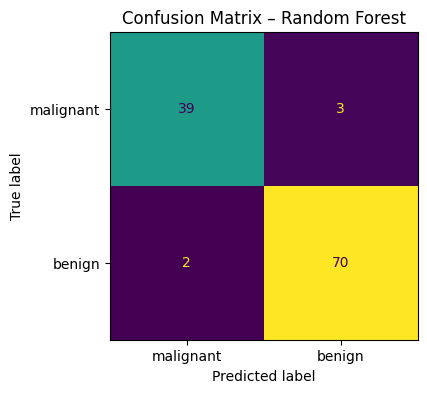

Explanation instance index : 0
True label : malignant  |  Predicted : malignant



In [ ]:
print("2. TRAINING RANDOM FOREST")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model.fit(X_train_s, y_train)

y_pred  = model.predict(X_test_s)
acc     = model.score(X_test_s, y_test)
print(f"Test accuracy : {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=class_names, ax=ax, colorbar=False
)
ax.set_title("Confusion Matrix – Random Forest")
plt.show()


mal_indices = np.where(model.predict(X_test_s) == 0)[0]
instance_idx = mal_indices[0]
instance     = X_test_s[instance_idx]
true_label   = class_names[y_test[instance_idx]]
pred_label   = class_names[model.predict([instance])[0]]
print(f"Explanation instance index : {instance_idx}")
print(f"True label : {true_label}  |  Predicted : {pred_label}\n")

## 3.  METHOD 1 – SHAP

3. SHAP EXPLANATIONS


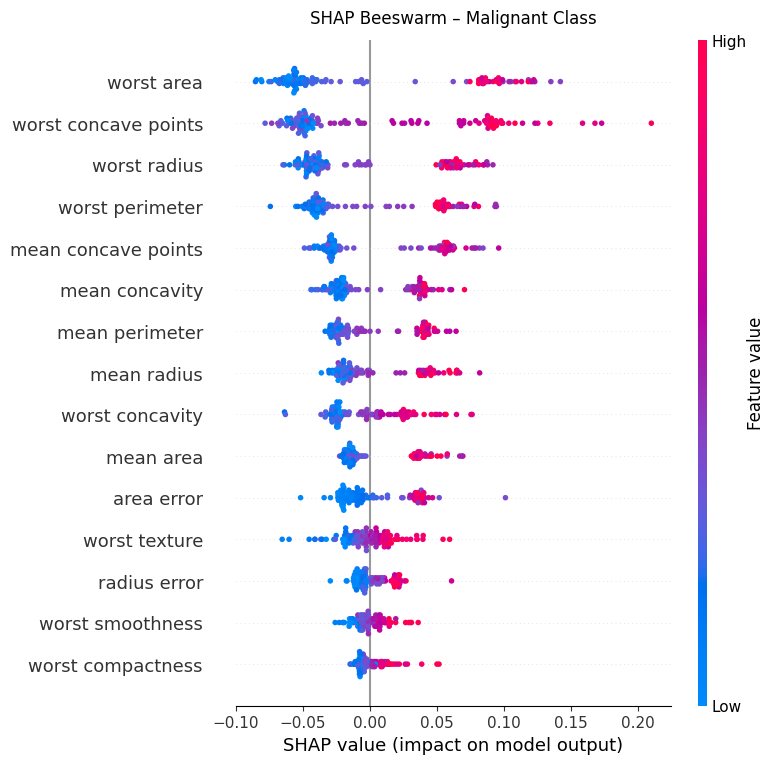

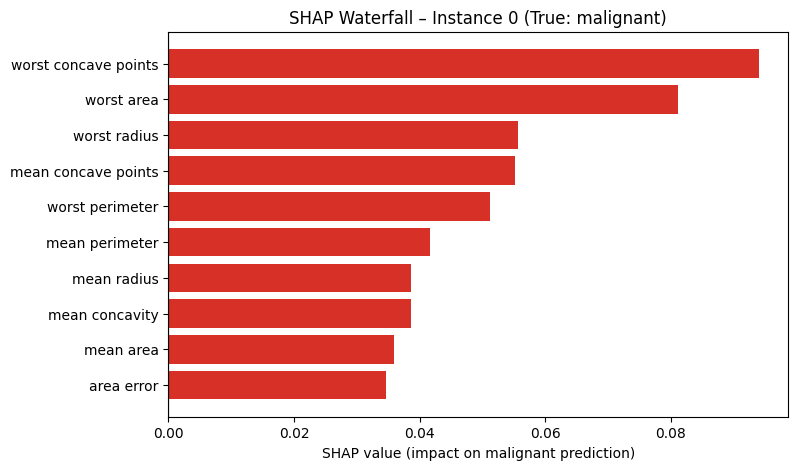


Top 5 SHAP features for instance 0 (malignant class):
  worst concave points                +0.0940  ↑ malignant
  worst area                          +0.0811  ↑ malignant
  worst radius                        +0.0557  ↑ malignant
  mean concave points                 +0.0551  ↑ malignant
  worst perimeter                     +0.0513  ↑ malignant



In [ ]:
print("3. SHAP EXPLANATIONS")

shap_explainer = shap.TreeExplainer(model)
shap_values    = shap_explainer.shap_values(X_test_s)
mean_abs_shap = np.mean(np.abs(shap_values[:, :, 0]), axis=0)

# Beeswarm plot – global feature importance for 'malignant' clas
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    shap_values[:, :, 0],   # class 0 = malignant
    X_test_s,
    feature_names=feature_names,
    class_names=class_names,
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP Beeswarm – Malignant Class", pad=12)
plt.show()

# Waterfall plot – single instance
shap_instance = shap_values[instance_idx, :, 0]   # malignant SHAP values
top_idx  = np.argsort(np.abs(shap_instance))[::-1][:10]
top_vals = shap_instance[top_idx]
top_names = [feature_names[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d73027" if v > 0 else "#4575b4" for v in top_vals]
ax.barh(top_names[::-1], top_vals[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value (impact on malignant prediction)")
ax.set_title(f"SHAP Waterfall – Instance {instance_idx} (True: {true_label})")
plt.show()

# Print top features for this instance
print(f"\nTop 5 SHAP features for instance {instance_idx} (malignant class):")
for name, val in zip(top_names[:5], top_vals[:5]):
    direction = "↑ malignant" if val > 0 else "↓ malignant"
    print(f"  {name:<35} {val:+.4f}  {direction}")
print()

## 4.  METHOD 2 – INTEGRATED GRADIENTS


4. INTEGRATED GRADIENTS
MLP surrogate accuracy : 0.9561  (RF accuracy: 0.9561)
Convergence delta (should be ~0): -0.003551

Top 5 IG attributions for instance 0 (malignant class):
  worst radius                        +1.1719  ↑ malignant
  mean texture                        +1.1636  ↑ malignant
  perimeter error                     +1.1272  ↑ malignant
  worst perimeter                     +1.1246  ↑ malignant
  worst area                          +1.0367  ↑ malignant


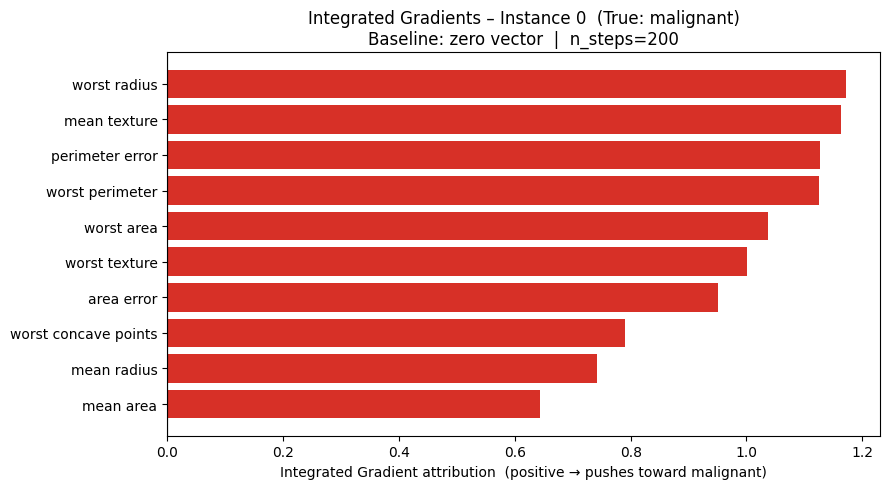

In [ ]:
print("4. INTEGRATED GRADIENTS")

# Train a small MLP as a differentiable surrogate
class MLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 64), nn.ReLU(),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

X_tr_t = torch.tensor(X_train_s, dtype=torch.float32)
y_tr_t  = torch.tensor(y_train,   dtype=torch.long)
mlp     = MLP(X_train_s.shape[1])
opt     = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(200):
    opt.zero_grad()
    loss_fn(mlp(X_tr_t), y_tr_t).backward()
    opt.step()

mlp.eval()
X_te_t   = torch.tensor(X_test_s, dtype=torch.float32)
mlp_preds = mlp(X_te_t).argmax(1).numpy()
mlp_acc   = (mlp_preds == y_test).mean()
print(f"MLP surrogate accuracy : {mlp_acc:.4f}  (RF accuracy: {acc:.4f})")

# Integrated Gradients on the chosen instance
ig       = IntegratedGradients(mlp)
baseline = torch.zeros(1, X_train_s.shape[1])   # zero vector baseline
instance_t = X_te_t[instance_idx].unsqueeze(0)

attrs, delta = ig.attribute(
    instance_t, baseline,
    target=0,                   # class 0 = malignant
    n_steps=200,                # number of steps for approximation
    return_convergence_delta=True
)
ig_attrs = attrs.detach().numpy()[0]
print(f"Convergence delta (should be ~0): {delta.item():.6f}")

# Sort by absolute attribution
ig_top_idx   = np.argsort(np.abs(ig_attrs))[::-1][:10]
ig_top_vals  = ig_attrs[ig_top_idx]
ig_top_names = [feature_names[i] for i in ig_top_idx]

print(f"\nTop 5 IG attributions for instance {instance_idx} (malignant class):")
for name, val in zip(ig_top_names[:5], ig_top_vals[:5]):
    print(f"  {name:<35} {val:+.4f}  {'↑' if val > 0 else '↓'} malignant")

# IG bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors_ig = ["#d73027" if v > 0 else "#4575b4" for v in ig_top_vals]
ax.barh(ig_top_names[::-1], ig_top_vals[::-1], color=colors_ig[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Integrated Gradient attribution  (positive → pushes toward malignant)")
ax.set_title(f"Integrated Gradients – Instance {instance_idx}  (True: {true_label})\n"
             f"Baseline: zero vector  |  n_steps=200")
plt.tight_layout()
plt.show()
print()


## 5.  METHOD 3 – ANCHORS

In [ ]:
print("5. ANCHOR EXPLANATIONS")

anchor_explainer = anchor_tabular.AnchorTabularExplainer(
    class_names   = class_names,
    feature_names = feature_names,
    train_data    = X_train_s
)

# Explain the instance
anchor_exp = anchor_explainer.explain_instance(
    instance,
    model.predict,
    threshold = 0.95,   # rule must hold in ≥95 % of similar cases
    delta = 0.1,
    tau = 0.15,
    beam_size = 4
)

anchor_rules     = anchor_exp.names()
anchor_precision = anchor_exp.precision()
anchor_coverage  = anchor_exp.coverage()


5. ANCHOR EXPLANATIONS


In [ ]:

#Rule
print("Anchor rule:")
print("IF")
for rule in anchor_rules:
    print(f"   {rule}")
print(f"THEN predict → {pred_label.upper()}")


# Metrics
metrics = (
    f"\n Anchor explanation metrics\n"
    f"Precision : {anchor_precision:.2%}\n"
    f"Coverage  : {anchor_coverage:.2%}\n\n"
)

print(metrics)

Anchor rule:
IF
   mean compactness > 0.49
   worst perimeter > 0.55
THEN predict → MALIGNANT

 Anchor explanation metrics
Precision : 99.24%
Coverage  : 14.69%

Interpretation:
- Precision means the rule holds for about 99% of similar instances.
- Coverage means the rule applies to about 15% of all test instances.



Computing Anchor stats on 10 test instances


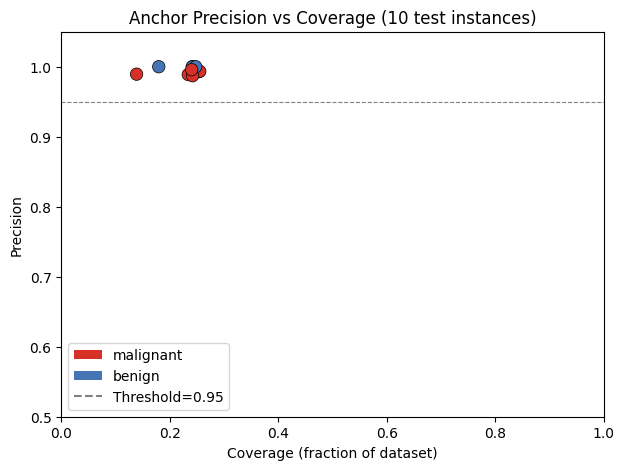

In [ ]:
# Precision vs Coverage across multiple instances
print("\nComputing Anchor stats on 10 test instances")
precisions, coverages, labels_list = [], [], []
sample_indices = np.random.choice(len(X_test_s), size=10, replace=False)

for idx in sample_indices:
    try:
        exp_i = anchor_explainer.explain_instance(
            X_test_s[idx], model.predict, threshold=0.95,
            delta=0.1, tau=0.15, beam_size=4
        )
        precisions.append(exp_i.precision())
        coverages.append(exp_i.coverage())
        labels_list.append(class_names[model.predict([X_test_s[idx]])[0]])
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(7, 5))
colors_pts = ["#d73027" if l == "malignant" else "#4575b4" for l in labels_list]
ax.scatter(coverages, precisions, c=colors_pts, s=80, edgecolors="k", linewidths=0.5)
ax.axhline(0.95, color="grey", linestyle="--", linewidth=0.8, label="Threshold=0.95")
ax.set_xlabel("Coverage (fraction of dataset)")
ax.set_ylabel("Precision")
ax.set_title("Anchor Precision vs Coverage (10 test instances)")
ax.set_xlim(0, 1); ax.set_ylim(0.5, 1.05)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#d73027", label="malignant"),
                   Patch(facecolor="#4575b4", label="benign")]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color="grey",
          linestyle="--", label="Threshold=0.95")])
plt.show()

## 6. METHOD 4 -COUNTERFACTUALS (DiCE)

100%|██████████| 1/1 [00:01<00:00,  1.64s/it]



DiCE: original pred=malignant, CF target=benign
Features changed per CF: [11, 10, 11]


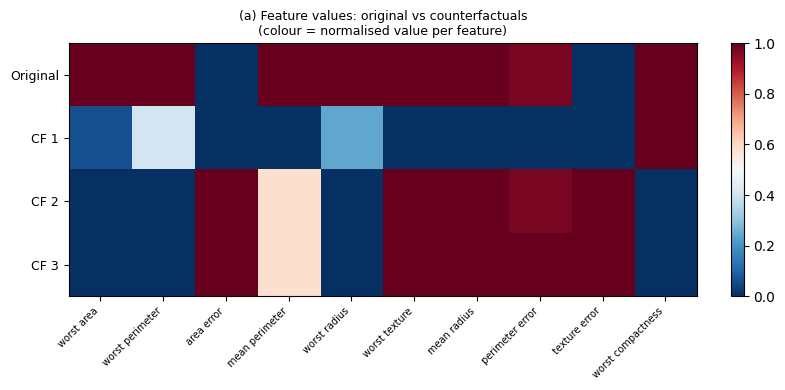

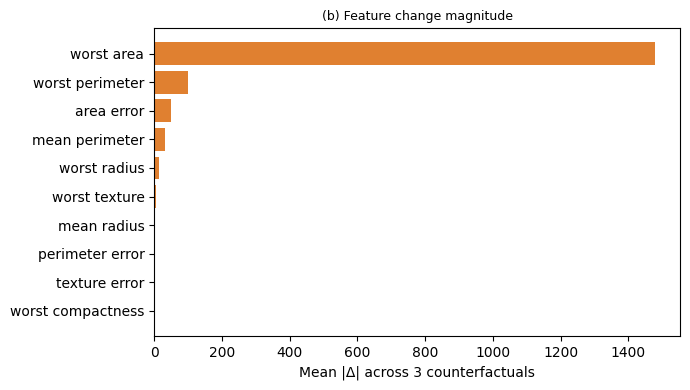

In [ ]:
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

data_dice = dice_ml.Data(
    dataframe=pd.concat(
        [X_train_df, pd.Series(y_train, name="target")],
        axis=1
    ),
    continuous_features=feature_names,
    outcome_name="target"
)

rf_dice = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_dice.fit(X_train, y_train)

model_dice = dice_ml.Model(model=rf_dice, backend="sklearn")
exp_dice   = Dice(data_dice, model_dice)

query_instance = X_test_df.iloc[[instance_idx]]
cf     = exp_dice.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite")
cf_df  = cf.cf_examples_list[0].final_cfs_df.copy()

orig_vals      = query_instance[feature_names].values[0]
cf_vals        = cf_df[feature_names].values
deltas         = cf_vals - orig_vals
mean_abs_delta = np.mean(np.abs(deltas), axis=0)
changed_idx    = np.argsort(mean_abs_delta)[::-1]
changed_idx    = changed_idx[mean_abs_delta[changed_idx] > 1e-6][:10]
top_delta_names = [feature_names[i] for i in changed_idx]

print(f"\nDiCE: original pred={pred_label}, CF target=benign")
print(f"Features changed per CF: {(np.abs(deltas) > 1e-6).sum(axis=1).tolist()}")

# (a) heatmap
fig_heat, ax_h = plt.subplots(figsize=(8, 4))
heat_data = np.vstack([orig_vals[changed_idx], cf_vals[:, changed_idx]])
heat_norm = (heat_data - heat_data.min(0)) / (np.ptp(heat_data, axis=0) + 1e-9)
im = ax_h.imshow(heat_norm, aspect="auto", cmap="RdBu_r", vmin=0, vmax=1)
ax_h.set_xticks(range(len(top_delta_names)))
ax_h.set_xticklabels(top_delta_names, rotation=45, ha="right", fontsize=7)
ax_h.set_yticks(range(len(cf_df)+1))
ax_h.set_yticklabels(["Original"]+[f"CF {i+1}" for i in range(len(cf_df))], fontsize=9)
ax_h.set_title("(a) Feature values: original vs counterfactuals\n"
               "(colour = normalised value per feature)", fontsize=9)
plt.colorbar(im, ax=ax_h, fraction=0.03)
plt.tight_layout()
plt.show(fig_heat)

# (b) delta bar chart
fig_bar, ax_b = plt.subplots(figsize=(7, 4))
ax_b.barh(top_delta_names[::-1],
          mean_abs_delta[changed_idx][::-1],
          color="#e08030")
ax_b.set_xlabel("Mean |Δ| across 3 counterfactuals")
ax_b.set_title("(b) Feature change magnitude", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Evaluation Experiment

EVALUATION EXPERIMENT

(A) Faithfulness – SHAP feature removal
  Remove top- 0 → accuracy=0.9561
  Remove top- 2 → accuracy=0.9561
  Remove top- 5 → accuracy=0.9649
  Remove top-10 → accuracy=0.7456
  Remove top-15 → accuracy=0.6316
  Remove top-20 → accuracy=0.6316

(B) Stability – IG Spearman ρ=1.0000  p=0.0000
  High stability ✓

(C) Completeness – Anchors across thresholds
  τ=0.80 → prec=0.9903  cov=0.1873  #rules=2
  τ=0.85 → prec=0.9925  cov=0.1409  #rules=2
  τ=0.90 → prec=0.9937  cov=0.2476  #rules=2
  τ=0.95 → prec=0.9896  cov=0.1947  #rules=2


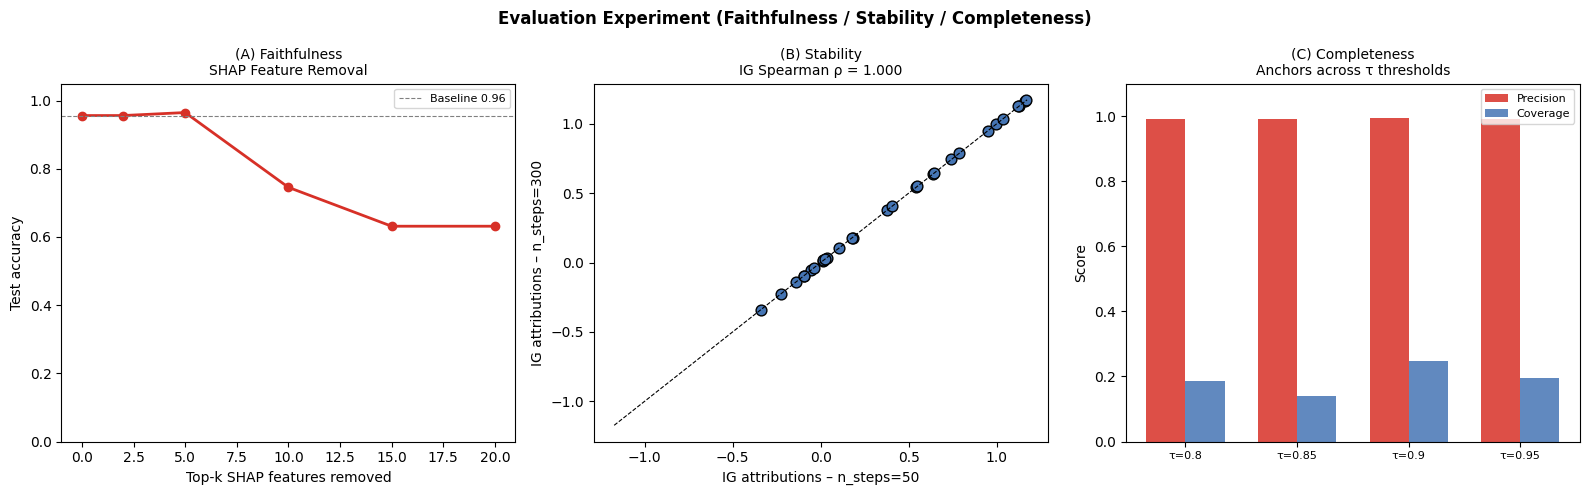

In [ ]:
# (A) Faithfulness  – SHAP feature removal → accuracy drop
# (B) Stability     – IG run twice with different n_steps → rank correlation
# (C) Completeness  – Anchors precision/coverage across τ thresholds
print("EVALUATION EXPERIMENT")

# (A) Faithfulness – SHAP feature removal
sorted_feat_idx  = np.argsort(mean_abs_shap)[::-1]
removal_steps    = [0, 2, 5, 10, 15, 20]
faithfulness_acc = []
print("\n(A) Faithfulness – SHAP feature removal")
for k in removal_steps:
    X_masked = X_test_s.copy()
    X_masked[:, sorted_feat_idx[:k]] = 0
    a = accuracy_score(y_test, model.predict(X_masked))
    faithfulness_acc.append(a)
    print(f"  Remove top-{k:2d} → accuracy={a:.4f}")

# (B) Stability – IG with two different n_steps settings
attrs_50, _  = ig.attribute(instance_t, baseline, target=0,
                             n_steps=50,  return_convergence_delta=True)
attrs_300, _ = ig.attribute(instance_t, baseline, target=0,
                             n_steps=300, return_convergence_delta=True)
ig_50  = attrs_50.detach().numpy()[0]
ig_300 = attrs_300.detach().numpy()[0]
rho_ig, pval_ig = spearmanr(ig_50, ig_300)
print(f"\n(B) Stability – IG Spearman ρ={rho_ig:.4f}  p={pval_ig:.4f}")
print(f"  {'High stability ✓' if rho_ig > 0.7 else 'Moderate stability'}")

# (C) Completeness – Anchors across thresholds
thresholds     = [0.80, 0.85, 0.90, 0.95]
thresh_results = []
print("\n(C) Completeness – Anchors across thresholds")
for tau in thresholds:
    try:
        e = anchor_explainer.explain_instance(
            instance, model.predict, threshold=tau, delta=0.1, tau=0.15, beam_size=4)
        thresh_results.append((tau, e.precision(), e.coverage(), len(e.names())))
        print(f"  τ={tau:.2f} → prec={e.precision():.4f}  "
              f"cov={e.coverage():.4f}  #rules={len(e.names())}")
    except Exception:
        print(f"  τ={tau:.2f} → failed")

# Evaluation dashboard (3 panels on one page)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A – Faithfulness
axes[0].plot(removal_steps, faithfulness_acc, "o-", color="#d73027", lw=2)
axes[0].axhline(acc, color="grey", ls="--", lw=0.8, label=f"Baseline {acc:.2f}")
axes[0].set_xlabel("Top-k SHAP features removed")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("(A) Faithfulness\nSHAP Feature Removal", fontsize=10)
axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8)

# Panel B – IG Stability scatter (n_steps=50 vs 300)
axes[1].scatter(ig_50, ig_300, color="#4575b4", edgecolors="k", s=60)
lim = max(max(abs(v) for v in list(ig_50) + list(ig_300)), 0.01)
axes[1].plot([-lim, lim], [-lim, lim], "k--", lw=0.8)
axes[1].set_xlabel("IG attributions – n_steps=50")
axes[1].set_ylabel("IG attributions – n_steps=300")
axes[1].set_title(f"(B) Stability\nIG Spearman ρ = {rho_ig:.3f}", fontsize=10)

# Panel C – Anchors Completeness
if thresh_results:
    taus_  = [r[0] for r in thresh_results]
    precs_ = [r[1] for r in thresh_results]
    covs_  = [r[2] for r in thresh_results]
    xp = np.arange(len(taus_)); w = 0.35
    axes[2].bar(xp-w/2, precs_, w, label="Precision", color="#d73027", alpha=0.85)
    axes[2].bar(xp+w/2, covs_,  w, label="Coverage",  color="#4575b4", alpha=0.85)
    axes[2].set_xticks(xp)
    axes[2].set_xticklabels([f"τ={t}" for t in taus_], fontsize=8)
    axes[2].set_ylabel("Score"); axes[2].set_ylim(0, 1.1)
    axes[2].set_title("(C) Completeness\nAnchors across τ thresholds", fontsize=10)
    axes[2].legend(fontsize=8)

fig.suptitle("Evaluation Experiment (Faithfulness / Stability / Completeness)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
